In [3]:
import pandas as pd
#read in a csv file from a url into a dataframe
data = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
frame = pd.DataFrame(data)
print(frame.head()) #prints the first 5 rows of the dataframe

frame.describe() #prints the summary statistics of the dataframe

frame[frame['species'] == 'setosa'].value_counts() #selecting all rows where species is setosa

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


sepal_length  sepal_width  petal_length  petal_width  species
4.3           3.0          1.1           0.1          setosa     1
5.2           3.5          1.5           0.2          setosa     1
5.0           3.6          1.4           0.2          setosa     1
5.1           3.3          1.7           0.5          setosa     1
              3.4          1.5           0.2          setosa     1
              3.5          1.4           0.2          setosa     1
                                         0.3          setosa     1
              3.7          1.5           0.4          setosa     1
              3.8          1.5           0.3          setosa     1
                           1.6           0.2          setosa     1
                           1.9           0.4          setosa     1
5.2           3.4          1.4           0.2          setosa     1
              4.1          1.5           0.1          setosa     1
4.4           2.9          1.4           0.2          setosa     1


In [4]:
frame.isna().sum() #prints the number of missing values in each column

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

how to deal with null values:

drop the entire row if even a single column contains a null value (throwing away the data of someone)
replace the null value with the average of all, median of all, or specific value using fillna

In [ ]:
frame_no_null = frame.dropna(inplace=True) #drops all rows with any missing values that are null but not recommended

# replace the null value with the average of the others
frame['sepal_length'].fillna(frame['sepal_length'].mean(), inplace=True) #replaces all missing values in sepal_length column with the mean of the column
#you could do mean median or a specific value

In [11]:
#dataframes have selection and projection capabilities

#selection
frame[frame['sepal_length'] > 5.0] #selecting all rows where sepal_length is greater than 5.0
#you could also see the number using .shape
frame[frame['sepal_length'] > 5.0].shape #gives you the number of rows and columns that satisfy the condition

#you can introduce multiple conditions using & and | operators
frame[(frame['sepal_length'] > 5.0) & (frame['species'] == 'setosa')] #selecting all rows where sepal_length is greater than 5

#projection
frame[(frame['sepal_length'] > 5.0) & (frame['species'] == 'setosa')][['sepal_length', 'species']] #selecting only sepal_length and species columns



#what about group by and aggregation?

#you can group by specific columns and do the mean of other columns
print(frame.groupby('species').mean()) #grouping by species and calculating the mean of all
#or
print(frame.groupby('species')['sepal_length'].mean()) #grouping by species and calculating

#group by one column and find the mean and standard deviation of another column
print(frame.groupby('species')['sepal_length'].agg(['mean', 'std'])) #group


#try this too
frame.groupby('species').agg({'sepal_length': ['mean', 'std'], 'sepal_width': ['mean', 'std']}) #grouping by species and calculating the mean and std of sepal_length and sepal_width columns
#you can also group by multiple columns
frame.groupby(['species', 'sepal_length']).agg({'sepal_length': ['mean', 'std'], 'sepal_width': ['mean', 'std']}) #grouping by species and sepal_length and calculating the mean and std of sepal_length and sepal_width columns






            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
species
setosa        5.006
versicolor    5.936
virginica     6.588
Name: sepal_length, dtype: float64
             mean       std
species                    
setosa      5.006  0.352490
versicolor  5.936  0.516171
virginica   6.588  0.635880


sepal_length      sepal_width          
                                mean  std        mean       std
species    sepal_length                                        
setosa     4.3                   4.3  NaN    3.000000       NaN
           4.4                   4.4  0.0    3.033333  0.152753
           4.5                   4.5  NaN    2.300000       NaN
           4.6                   4.6  0.0    3.325000  0.221736
           4.7                   4.7  0.0    3.200000  0.000000
           4.8                   4.8  0.0    3.180000  0.204939
           4.9                   4.9  0.0    3.200000  0.270801
           5.0                   5.0  0.0    3.362500  0.192261
           5.1                   5.1  0.0    3.600000  0.200000
           5.2                   5.2  0.0    3.666667  0.378594
           5.3                   5.3  NaN    3.700000       NaN
           5.4                   5.4  0.0    3.660000  0.250998
           5.5                   5.5  0.0    3.850000  0.494975
           5.7                   5.7  0.0    4.100000  0.424264
           5.8                   5.8  NaN    4.000000       NaN
versicolor 4.9                   4.9  NaN    2.400000       NaN
           5.0                   5.0  0.0    2.150000  0.212132
           5.1                   5.1  NaN    2.500000       NaN
           5.2                   5.2  NaN    2.700000       NaN
           5.4                   5.4  NaN    3.000000       NaN
           5.5                   5.5  0.0    2.440000  0.114018
           5.6                   5.6  0.0    2.820000  0.216795
           5.7                   5.7  0.0    2.820000  0.148324
           5.8                   5.8  0.0    2.666667  0.057735
           5.9                   5.9  0.0    3.100000  0.141421
           6.0                   6.0  0.0    2.800000  0.496655
           6.1                   6.1  0.0    2.875000  0.095743
           6.2                   6.2  0.0    2.550000  0.494975
           6.3                   6.3  0.0    2.700000  0.529150
           6.4                   6.4  0.0    3.050000  0.212132
           6.5                   6.5  NaN    2.800000       NaN
           6.6                   6.6  0.0    2.950000  0.070711
           6.7                   6.7  0.0    3.066667  0.057735
           6.8                   6.8  NaN    2.800000       NaN
           6.9                   6.9  NaN    3.100000       NaN
           7.0                   7.0  NaN    3.200000       NaN
virginica  4.9                   4.9  NaN    2.500000       NaN
           5.6                   5.6  NaN    2.800000       NaN
           5.7                   5.7  NaN    2.500000       NaN
           5.8                   5.8  0.0    2.733333  0.057735
           5.9                   5.9  NaN    3.000000       NaN
           6.0                   6.0  0.0    2.600000  0.565685
           6.1                   6.1  0.0    2.800000  0.282843
           6.2                   6.2  0.0    3.100000  0.424264
           6.3                   6.3  0.0    2.933333  0.350238
           6.4                   6.4  0.0    2.920000  0.216795
           6.5                   6.5  0.0    3.050000  0.100000
           6.7                   6.7  0.0    3.040000  0.328634
           6.8                   6.8  0.0    3.100000  0.141421
           6.9                   6.9  0.0    3.133333  0.057735
           7.1                   7.1  NaN    3.000000       NaN
           7.2                   7.2  0.0    3.266667  0.305505
           7.3                   7.3  NaN    2.900000       NaN
           7.4                   7.4  NaN    2.800000       NaN
           7.6                   7.6  NaN    3.000000       NaN
           7.7                   7.7  0.0    3.050000  0.525991
           7.9                   7.9  NaN    3.800000       NaN

In [ ]:
#default value of crosstab is count
pd.crosstab(frame['species'], frame['sepal_length']) #gives the count of each sepal_length for each species
#you can also do aggregation
pd.crosstab(frame['species'], frame['sepal_length'], values=frame['sepal_width'], aggfunc='mean') #gives the mean of sepal_width for each sepal_length for each species


#crosstab is cross tabulation which is a special case of group by and aggregation what it does is it takes two columns and creates a matrix of the counts of the values in those columns



#you can also do pv.pivot_table
pd.pivot_table(frame, values='sepal_width', index='species', columns='sepal_length', aggfunc='mean') #gives the mean of sepal_width for each sepal_length for each species

#the difference between crosstab and pivot_table is that crosstab is used for categorical data while pivot_table is used for numerical data


sepal_length,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0,5.1,5.2,...,6.8,6.9,7.0,7.1,7.2,7.3,7.4,7.6,7.7,7.9
species,,,,,,,,,,,,,,,,,,,,,
setosa,3.0,3.033333,2.3,3.325,3.2,3.18,3.2,3.3625,3.6,3.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
versicolor,NaN,NaN,NaN,NaN,NaN,NaN,2.4,2.1500,2.5,2.700000,...,2.8,3.100000,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
virginica,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,3.1,3.133333,NaN,3.0,3.266667,2.9,2.8,3.0,3.05,3.8


In [ ]:
#.sort_values
frame.sort_values(by='sepal_length', ascending=False) #sorts the dataframe by sepal_length in descending order

#you can also do .head which gives you the first n rows of the dataframe
frame.sort_values(by='sepal_length', ascending=False).head() #.head by default gives you the first 5 rows of the dataframe
frame.sort_values(by='sepal_length', ascending=False).head(10) #gives you the first 10 rows of the dataframe

<Axes: >

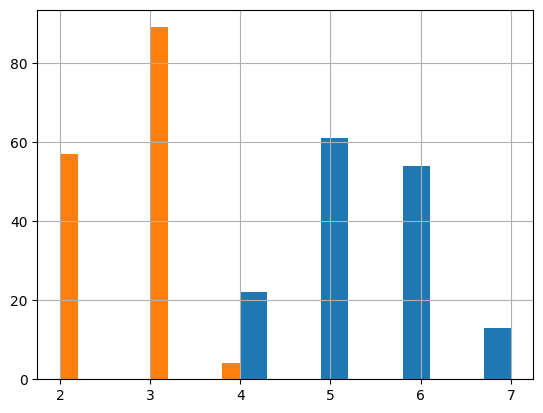

In [17]:
frame['sepal_length'].astype('int').hist(bins=10) #converts the sepal_length column to int and then plots a histogram with 10 bins
frame['sepal_width'].astype('int').hist() 

   rank discipline  phd  service   sex  salary
0  Prof          B   56       49  Male  186960
1  Prof          A   12        6  Male   93000
2  Prof          A   23       20  Male  110515
3  Prof          A   40       31  Male  131205
4  Prof          B   20       18  Male  104800


<Axes: >

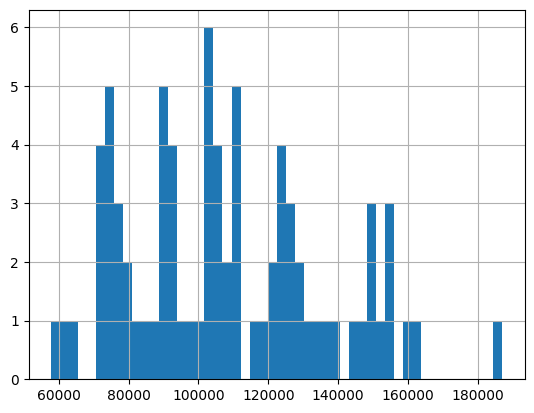

In [ ]:
#law of large numbers

#find a dataset full of salaries from a url and read it into a dataframe
salaries_frame = pd.read_csv("https://an-utd-python.s3-us-west-1.amazonaws.com/Salaries.csv")
print(salaries_frame.head()) #prints the first 5 rows of the dataframe
#

plotting and visualization:

1. univariate

2. multivariable
    - y vs x plots
        scatterplots

python had matplotlib and that was kinda fucked

so then seaborn was made, making it easier to use than matplotlib

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

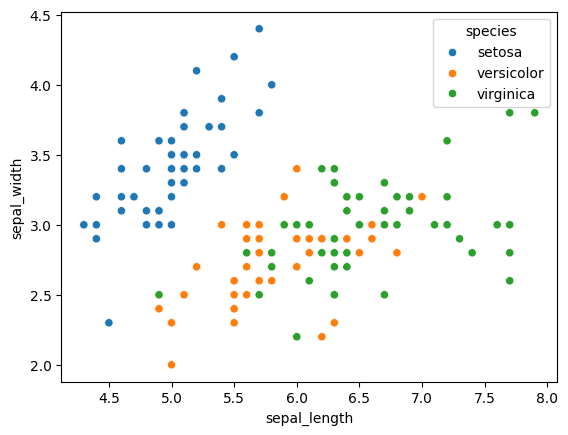

In [23]:
import seaborn as sns
#seaborn is a python library for data visualization built on top of matplotlib
#it provides a high-level interface for drawing attractive and informative statistical graphics

sns.scatterplot(data=frame, x='sepal_length', y='sepal_width', hue='species') #scatterplot of sepal_length vs sepal_width colored by species    

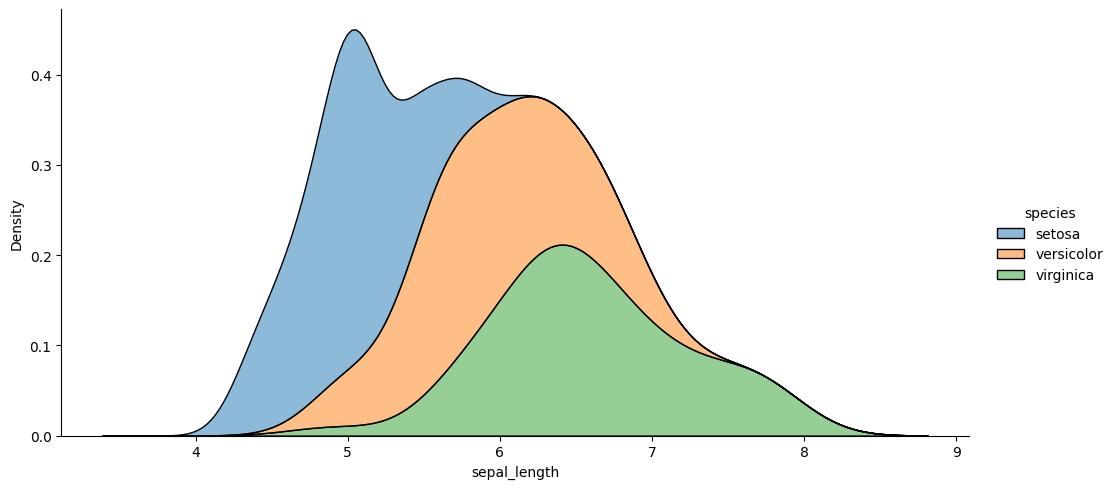

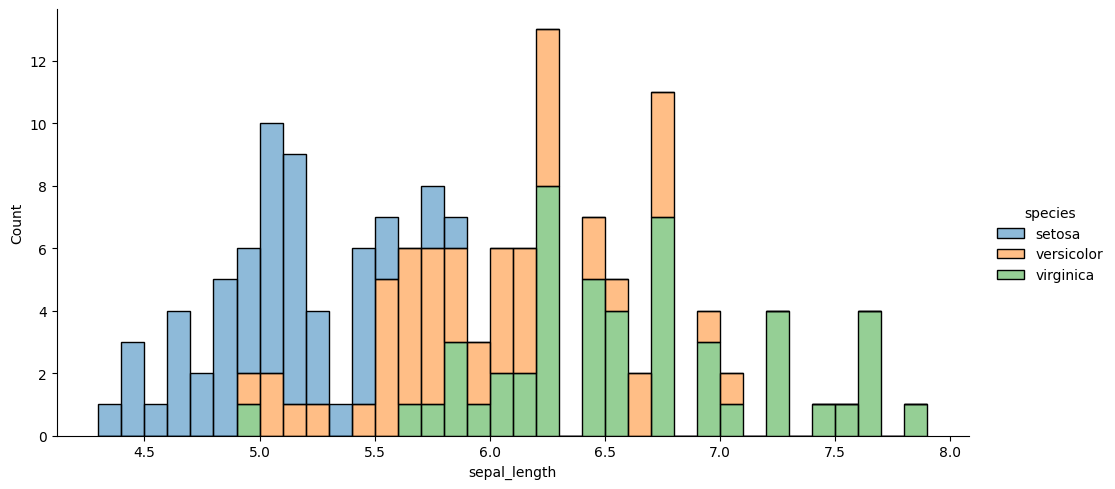

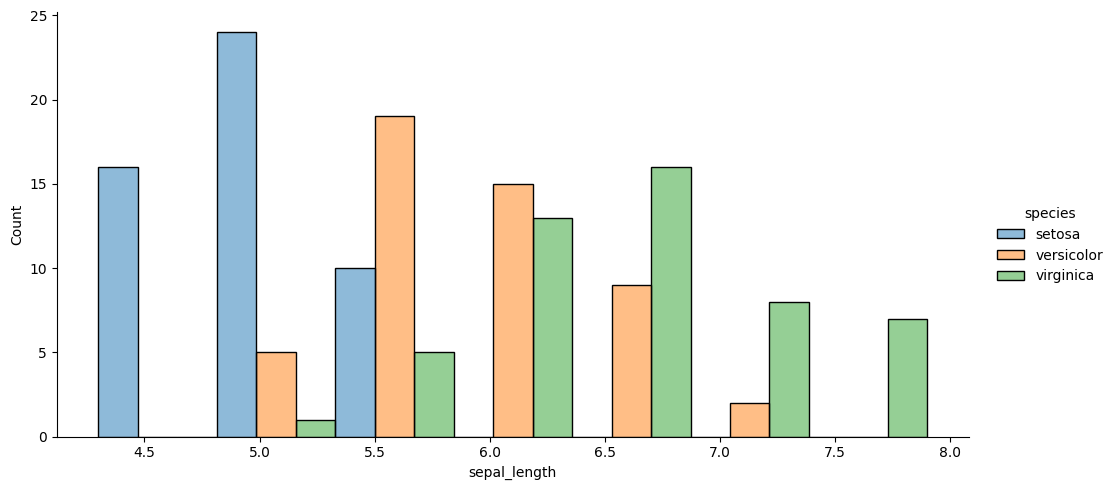

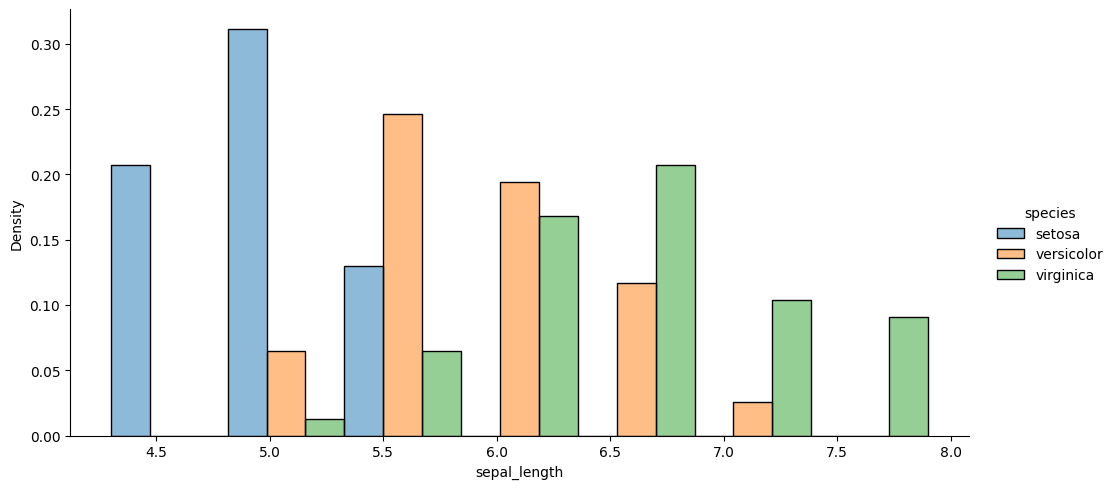

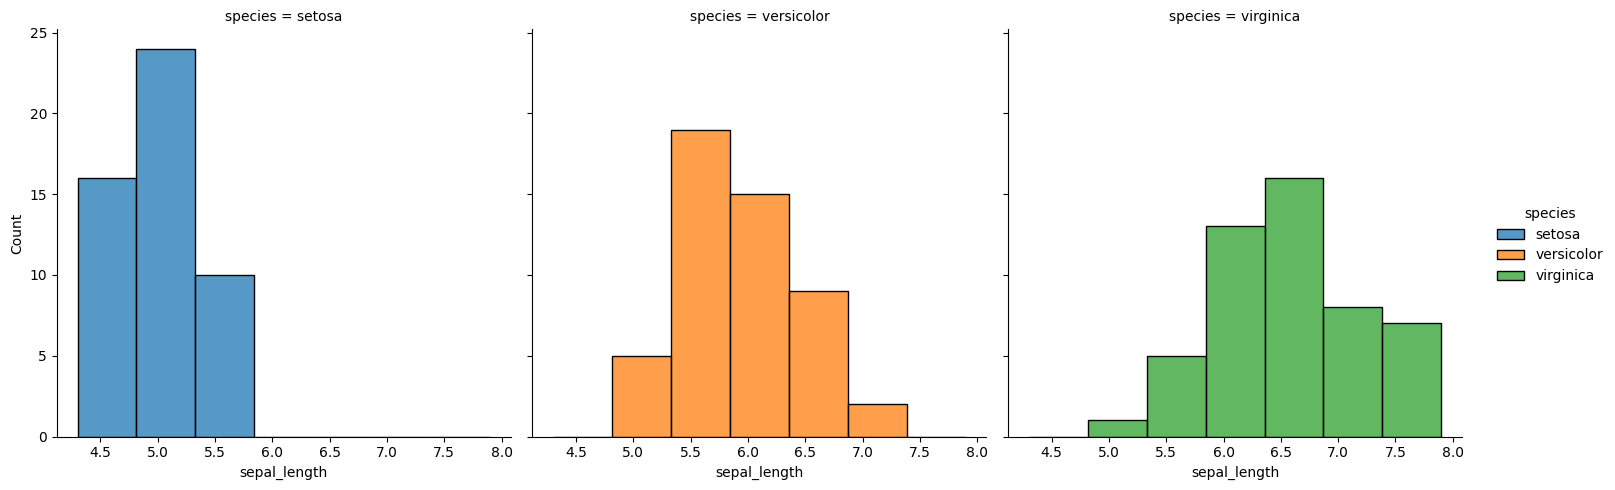

In [ ]:
#kind kde will create a density plot
sns.displot(data=frame, x='sepal_length', hue='species', kind='kde', fill=True, alpha=0.5, multiple="stack", height=5, aspect=2) 
#distribution plot of sepal_length colored by species

sns.displot(data=frame, x='sepal_length', hue='species', binwidth=0.1, fill=True, alpha=0.5, multiple="stack", height=5, aspect=2) 
#you can color code any categorical variable using hue

sns.displot(data=frame, x='sepal_length', hue='species', binwidth=0.5, fill=True, alpha=0.5, multiple="dodge", height=5, aspect=2) 

sns.displot(data=frame, x='sepal_length', hue='species', binwidth=0.5, fill=True, alpha=0.5, multiple="dodge", height=5, aspect=2, stat='density')

sns.displot(data=frame, x='sepal_length', hue='species', binwidth=0.5, multiple="stack", col='species', height=5, aspect=1)





#there is also plotly and bokeh for interactive plots but they are not covered in this class

#plotly is a graphing library that makes interactive, publication-quality graphs online

#import plotly.express as px
#fig = px.scatter(frame, x='sepal_length', y='sepal_width', color='species')


#bp shell, shlumberger are oil and gas companies that higher data scientists
#utsw medical center also hires data scientists, utmb
#show the plot

In [70]:
#tips dataset
tips = sns.load_dataset('tips')
tips_frame = pd.DataFrame(tips)
print(tips_frame.head()) #prints the first 5 rows of the dataframe
tips.shape

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


(244, 7)

In [74]:
#how to compute the tip percentage
#.apply applies a for loop that goes through each row, in this case we are applying a lambda function that takes in a row and returns the tip percentage
tips_frame['tip_percentage'] = tips.apply(lambda row: (row['tip'] / row['total_bill']) * 100, axis=1)
tips_frame.head()

#instead of using a lambda function you can also define a function and then use it
def compute_tip_percentage(row):
    return (row['tip'] / row['total_bill']) * 100

tips_frame['tip_percentage_2'] = tips.apply(compute_tip_percentage, axis=1)
tips_frame.head()

tips_frame['tip_percentage_2'].describe()

count    244.000000
mean      16.080258
std        6.107220
min        3.563814
25%       12.912736
50%       15.476977
75%       19.147549
max       71.034483
Name: tip_percentage_2, dtype: float64

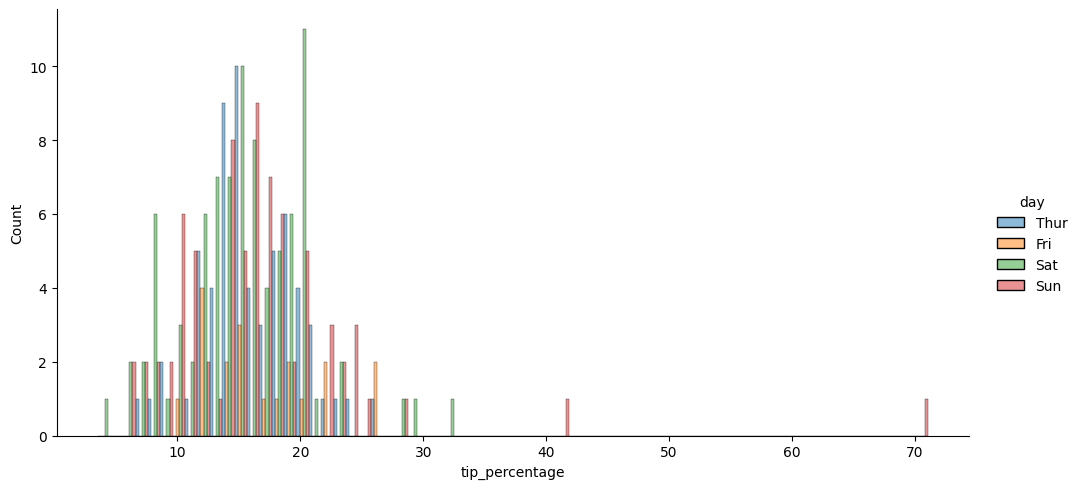

In [84]:
sns.displot(data=tips_frame, x='tip_percentage', binwidth=1, fill=True, alpha=0.5, height=5, aspect=2, hue='day', multiple="dodge")